In [ ]:
from pathlib import Path
import sys
import pandas as pd
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from datetime import datetime

import os
import numpy as np
import matplotlib.pyplot as plt

# 4) imports
import torch
from main_model import CSDI_base
from yahoo_data import get_dataloader, FinancialDataset


In [ ]:
ticker = "AAPL"
start_date = "2010-01-01"
end_date = "2024-12-31"

# training parameters
sequence_length = 252
validation_ratio = 0.2

execute_train = False
load_outputs = True
checkpoint_path = "../checkpoints/final_model.pth"
num_samples = 100
date_to_load = "2026-01-08"

output_file = "AAPL_2010-01-01_2024-12-31_2026-40-09_csdi_out.pt"

In [ ]:
# 1) go back to parent folder
p1 = Path.cwd().parent

# 2) go back to parent of the parent
p2 = Path.cwd().parent.parent

# 3) enter folder "CSDI" (assumed to be inside that parent-of-parent)
csdi_dir = p2 / "CSDI"

# Make sure it exists (optional but recommended)
if not csdi_dir.is_dir():
    raise FileNotFoundError(f"Folder not found: {csdi_dir}")

# Add CSDI to Python import path so imports work from anywhere
sys.path.insert(0, str(csdi_dir))

dataset_dir = p1 / "data"
config_dir = p1 / "configs"

sys.path.insert(0, str(dataset_dir))

# Checkpoints

In [ ]:
import json
with open(f"../checkpoints/{ticker}_training_history_{date_to_load}.json", "r") as f:
    history = json.load(f)

In [ ]:
history_df = pd.DataFrame(history)
history_df.describe()

# Output

In [ ]:
# Define the path to your saved file
load_path = f"../outputs/{output_file}"

# Load the dictionary
# Note: Since you saved with .cpu(), these will load onto the CPU by default
loaded_payload = torch.load(load_path, map_location='cpu')

# Unpack the variables
samples = loaded_payload["samples"]           # Shape: [n_samples, batch, features, length]
observed = loaded_payload["observed"]         # The original ground truth data
target_mask = loaded_payload["target_mask"]   # Mask for what was generated
obs_mask = loaded_payload["obs_mask"]         # Mask for what was provided as condition
obs_tp = loaded_payload["obs_tp"]             # Time points/indices
num_samples = loaded_payload["n_samples"]     # The scalar value for count

print(f"Loaded samples with shape: {samples.shape}")

No masked target points found for Returns_z (target_mask is all zeros).


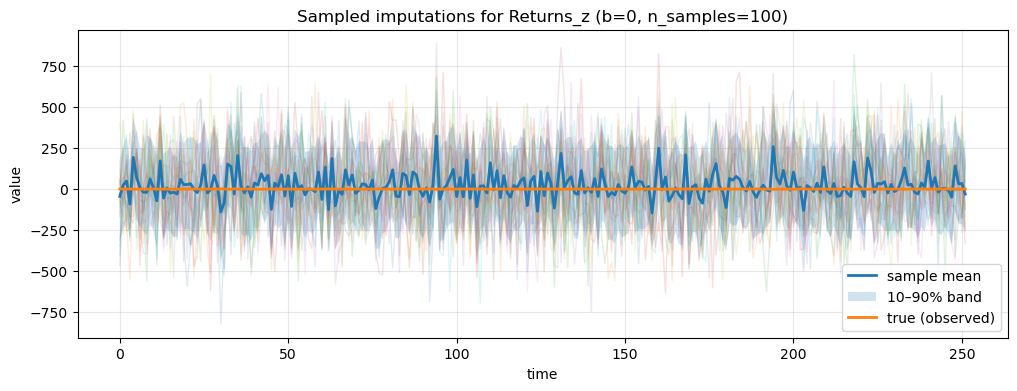

In [ ]:
# ==== Visualize sampled imputations (add this at the end of the notebook) ====

# If your environment sometimes crashes on plt.show(), set this True to save PNGs instead.
SAVE_PLOTS = False
OUTDIR = "../checkpoints/figures"
os.makedirs(OUTDIR, exist_ok=True)

# ---- Safety checks: these must exist from your evaluate() cell ----
required = ["samples", "observed", "target_mask", "obs_tp"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables {missing}. Run the cell that calls model.evaluate(...) first."
    )

# ---- Pick which item in batch and which feature to visualize ----
b = 0  # batch index
K = samples.shape[2]
L = samples.shape[3]

# Adjust these names / index if your feature order differs:
feature_names = ["Open_rel", "High_rel", "Low_rel", "Volume_z", "Returns_z"]
if len(feature_names) != K:
    feature_names = [f"feat_{i}" for i in range(K)]

returns_idx = 4 if K >= 5 else 0  # change if needed

# ---- Move to CPU numpy ----
S = samples[b].detach().cpu().numpy()       # (n_samples, K, L)
X = observed[b].detach().cpu().numpy()      # (K, L)
TM = target_mask[b].detach().cpu().numpy()  # (K, L)

# time axis
tp = obs_tp
if tp.dim() == 2:
    t = tp[b].detach().cpu().numpy()
else:
    t = np.arange(L)

# ---- Compute summary statistics of samples ----
pred_mean = S.mean(axis=0)                        # (K, L)
pred_q10, pred_q90 = np.quantile(S, [0.1, 0.9], axis=0)  # (K, L) each

# ---- Metric on masked (target) points for the selected feature ----
mask_pos = TM[returns_idx].astype(bool)
if mask_pos.any():
    rmse = np.sqrt(np.mean((pred_mean[returns_idx, mask_pos] - X[returns_idx, mask_pos]) ** 2))
    mae = np.mean(np.abs(pred_mean[returns_idx, mask_pos] - X[returns_idx, mask_pos]))
    print(f"Imputation quality on masked points ({feature_names[returns_idx]}): RMSE={rmse:.6g}, MAE={mae:.6g}")
else:
    print(f"No masked target points found for {feature_names[returns_idx]} (target_mask is all zeros).")

# ---- Plot: true series vs sampled imputations (spaghetti + mean + 10–90 band) ----
n_show = min(20, S.shape[0])

plt.figure(figsize=(12, 4))
for i in range(n_show):
    plt.plot(t, S[i, returns_idx], alpha=0.15, linewidth=1)

plt.plot(t, pred_mean[returns_idx], linewidth=2, label="sample mean")
plt.fill_between(t, pred_q10[returns_idx], pred_q90[returns_idx], alpha=0.2, label="10–90% band")
plt.plot(t, X[returns_idx], linewidth=2, label="true (observed)")

if mask_pos.any():
    plt.scatter(t[mask_pos], X[returns_idx, mask_pos], s=25, label="masked target points")

plt.title(f"Sampled imputations for {feature_names[returns_idx]} (b={b}, n_samples={S.shape[0]})")
plt.xlabel("time")
plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.legend()

if SAVE_PLOTS:
    path = os.path.join(OUTDIR, f"samples_{feature_names[returns_idx]}_b{b}.png")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    print("Saved:", path)
else:
    plt.show()

# ---- Optional: histogram of sampled values at one masked timestep ----
if mask_pos.any():
    idx0 = np.where(mask_pos)[0][0]  # first masked timestep
    vals = S[:, returns_idx, idx0]   # (n_samples,)

    plt.figure(figsize=(6, 3))
    plt.hist(vals, bins=30)
    plt.axvline(X[returns_idx, idx0], linewidth=2, label="true")
    plt.axvline(pred_mean[returns_idx, idx0], linewidth=2, label="mean")
    plt.title(f"Distribution of samples at t={idx0} ({feature_names[returns_idx]})")
    plt.xlabel("sampled value")
    plt.ylabel("count")
    plt.grid(True, alpha=0.3)
    plt.legend()

    if SAVE_PLOTS:
        path = os.path.join(OUTDIR, f"hist_{feature_names[returns_idx]}_b{b}_t{idx0}.png")
        plt.tight_layout()
        plt.savefig(path, dpi=150)
        plt.close()
        print("Saved:", path)
    else:
        plt.show()
